## Fitting the transfer function of RS neurons — **explicit adaptation** (`w_ad != 0`)

Companion to `TF_fitting_RS.ipynb`. That notebook fits the *stationary* (delayed) data
with `w_ad = 0`, so the adaptation is baked into the polynomial. Here we instead supply
the adaptation current `w_ad` explicitly for each data point, so the fitted polynomial
represents the true transfer function `F(nu_e, nu_i, W)` and `W` can be evolved as a
dynamical variable in the mean field.

Data source: the **no-delay** RS sweep (`TF_data_extraction_RS.py`, delay = 0).

#### Ilaria Carannante
mailto: ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

In [1]:
#%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..', '..',))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from ntmf.neurons import setting_simulation_Brian, voltage_clamp_synapse, AdEx_eqs
from ntmf.network import network_creation, extracting_pop_freq_and_std, extracting_single_pop_freq_and_std
from utils.Plots_helper import *
from ntmf.transfer_function import *
from ntmf.optimization import run_fits, discrete_alpha_search
from ntmf.config import get_params_model_SI, get_network_config, adding_K_params
from scipy.optimize import minimize
import numpy as np
import pandas as pd
import json

In [4]:
import os
# Setting file saving
figs = []
fig_path = os.path.join('figures')
isExist = os.path.exists(fig_path)
if not isExist:
   os.makedirs(fig_path)
   print('The directory "figures" is created.')

def save_figs(fig_path, name, figs):
    pdf_file_path = os.path.join(fig_path, name + '-figs.pdf')
    with PdfPages(pdf_file_path) as ofile:
        for fig in figs:
            ofile.savefig(fig)

In [5]:
results_path = os.path.join('results')
isExist = os.path.exists(results_path)
if not isExist:
   os.makedirs(results_path)
   print('The directory "results" is created.')

In [6]:
neuron_model = 'RS'

In [7]:
import os
parent_dir = os.path.abspath('.')
fig_name = 'TF_fitting_RS_wad'
saving_json = False
out_file_name = 'results_RS_wad.json'   # separate file so approach (1) is not overwritten
# alpha handling: if opt_alpha is False and no alpha_results file exists, alpha = 1
opt_alpha = False
display_gif = False
gif_name = os.path.join('..', '..', 'GIF_folder', f'TF_fitting_{neuron_model}.gif')

## Setting up the neuron model

In [8]:
data_folder = '../../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

In [9]:
params_SI = get_params_model_SI(neuron_model = neuron_model,
                             json_file_name = os.path.join(data_folder, neuron_model + '.json'))

## Reading in network configuration

In [10]:
network_config_folder = '../../config/'
network_file_name = 'network_config_file_v0.json'

In [11]:
network_config = get_network_config(json_file_name =  os.path.join(network_config_folder, network_file_name))

In [12]:
params_SI = adding_K_params(neuron_params = params_SI,
                            network_config = network_config)

In [13]:
# Inspect available keys so we can pick out the adaptation parameters below
print(sorted(params_SI.keys()))
params_SI

['C_m', 'Delta_T', 'E_L', 'E_e', 'E_i', 'K_e', 'K_i', 'Q_e', 'Q_i', 'V_peak', 'V_reset', 'V_th', 'a', 'b', 'g_L', 't_ref', 'tau_syn', 'tau_w']


{'C_m': 2.0000000000000003e-10,
 'g_L': 1e-08,
 'E_L': -0.065,
 'a': 0.0,
 'b': 1.0000000000000002e-10,
 'tau_w': 0.5,
 'V_th': -0.05,
 'Delta_T': 0.002,
 'V_reset': -0.065,
 'V_peak': 0.0,
 't_ref': 0.005,
 'E_e': 0.0,
 'Q_e': 1.5000000000000002e-09,
 'E_i': -0.08,
 'Q_i': 5e-09,
 'tau_syn': 0.005,
 'K_e': 400.0,
 'K_i': 100.0}

## Adaptation parameters (`a`, `b`, `tau_w`)

These are required to reconstruct the adaptation current `w_ad` for each data point.
They must be in SI units (a in S, b in A, tau_w in s) — `get_params_model_SI` should
already have converted them. The lookup below is defensive about key naming; adjust the
candidate names if your JSON uses different ones.

In [14]:
def _get(params, names):
    for n in names:
        if n in params:
            return float(params[n]), n
    raise KeyError(f"None of {names} found in params_SI. Available: {sorted(params)}")

a_w,   a_key  = _get(params_SI, ['a', 'a_w', 'a_adapt'])
b_w,   b_key  = _get(params_SI, ['b', 'b_w', 'b_adapt'])
tau_w, tw_key = _get(params_SI, ['tau_w', 'tau_adapt', 'tauw'])

print(f'a     = {a_w:.4g} S     (key: {a_key})')
print(f'b     = {b_w:.4g} A     (key: {b_key})')
print(f'tau_w = {tau_w:.4g} s   (key: {tw_key})')

assert b_w >= 0, 'b (spike-triggered adaptation) should be >= 0 for RS'

a     = 0 S     (key: a)
b     = 1e-10 A     (key: b)
tau_w = 0.5 s   (key: tau_w)


## Reading in matrix inh-exc (no-delay dataset)

In [15]:
simulation_folder = '../data_extraction/simulations/TF_RS_w_v1'

In [16]:
# --- Load the data ---
df_RS = pd.read_csv(
    os.path.join(simulation_folder, 'testing_TF_data_RS_w.dat'),
    sep=r'\s+',
    header = 0
)
print(df_RS.columns.tolist())
df_RS.head()

['input_inh', 'input_exc', 'avg_f_out', 'std_f_out', 'avg_w']


,input_inh,input_exc,avg_f_out,std_f_out,avg_w
0,0.0,0.0,0.00,0.00,0.000000e+00
1,0.0,0.5,0.14,0.39,6.049060e-12
2,0.0,1.0,1.89,0.65,8.398490e-11
3,0.0,1.5,3.51,0.47,1.550040e-10
4,0.0,2.0,5.24,0.72,2.303980e-10


In [17]:
inh_vals = sorted(df_RS['input_inh'].unique())
exc_vals = sorted(df_RS['input_exc'].unique())

In [18]:
# Slicing the data (for the heatmap / mesh diagnostics)
x_s = sorted(df_RS['input_exc'].unique())
y_s = sorted(df_RS['input_inh'].unique())

df_RS_slice_array     = df_RS['avg_f_out'].to_numpy().reshape(len(y_s), len(x_s))
df_std_RS_slice_array = df_RS['std_f_out'].to_numpy().reshape(len(y_s), len(x_s))

## Adaptation current per data point

We need the value of `W = <w_ad>` at which each `(nu_e, nu_i) -> avg_f_out` point was
measured.

1. **Preferred:** if the Brian2 script saved the mean adaptation over the measurement
   window (column `avg_w` / `w_ad` / `mean_w`), we use it directly. This is exact even
   when the window includes the transient.
2. **Fallback (di Volo steady state):** `W_stat = a (mu_V - E_L) + b * tau_w * nu_out`,
   solved self-consistently because `mu_V` itself depends on `W`. This assumes the
   measurement is stationary.

The value must be in Amps (SI), consistent with `g_L * E_L` in `membrane_potential_fluctuations`.

In [19]:
def stationary_w_ad(data, params, a, b, tau_w, n_iter=6):
    """Self-consistent stationary adaptation current W_stat (Amps), per data row."""
    nu = np.maximum(data['avg_f_out'].to_numpy(), 0.0)
    w  = b * tau_w * nu                       # spike-triggered part (initial guess)
    for _ in range(n_iter):
        mu_V, _, _, _ = membrane_potential_fluctuations(data=data, params=params, w_ad=w)
        w = a * (mu_V - params['E_L']) + b * tau_w * nu
    return w

recorded_cols = [c for c in ['avg_w', 'w_ad', 'mean_w', 'w_mean'] if c in df_RS.columns]
if recorded_cols:
    col = recorded_cols[0]
    w_ad = df_RS[col].to_numpy().astype(float)
    print(f"Using recorded adaptation column '{col}' (assumed SI, Amps).")
else:
    w_ad = stationary_w_ad(df_RS, params_SI, a_w, b_w, tau_w)
    print('No recorded adaptation column found - using self-consistent W_stat.')

print(f'w_ad range: [{w_ad.min():.3e}, {w_ad.max():.3e}] A')

Using recorded adaptation column 'avg_w' (assumed SI, Amps).
w_ad range: [0.000e+00, 3.498e-09] A


## Computing membrane potential fluctuations (with adaptation)

In [20]:
mu_V, sig_V, tau_V, tau_V_norm = membrane_potential_fluctuations(
    data = df_RS, params = params_SI, w_ad = w_ad)

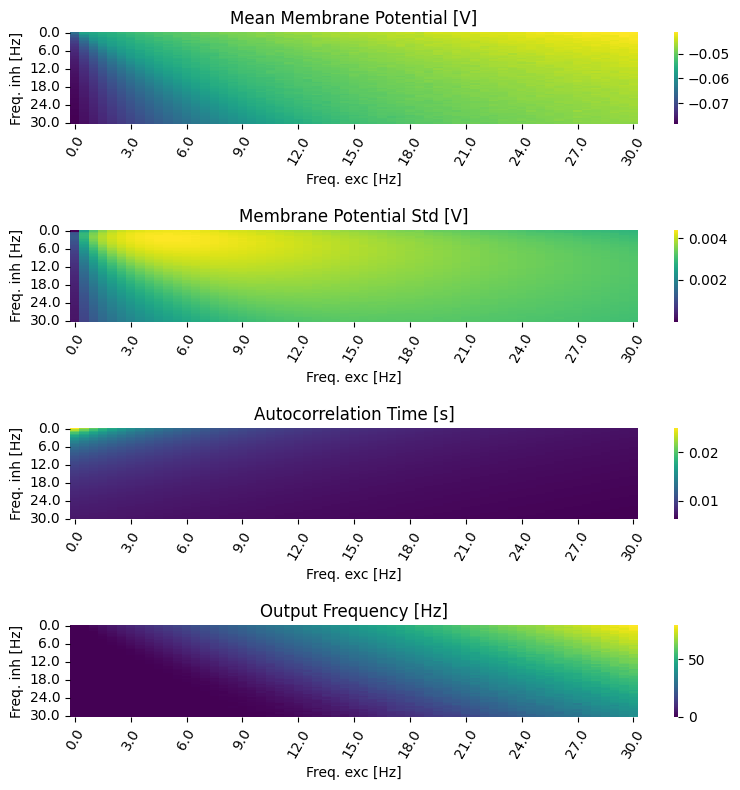

In [21]:
fig = plot_membrane_potential_fluctuations(data = df_RS, mu_V = mu_V, sig_V = sig_V, tau_V = tau_V)
figs.append(fig)

## Selecting alpha

`alpha` is fitted jointly with the polynomial against the data, so an alpha selected
on the `w_ad = 0` characterisation does not transfer here: hyperpolarising mu_V by W
moves the optimum. We therefore run `discrete_alpha_search` on the adapted data, with
the same `w_ad` used for `mu_V`/`sig_V`/`tau_V` above.

Results go to a `_wad`-suffixed file so the approach-(1) alpha sweep is not overwritten.

In [22]:
folder_name = os.path.basename(simulation_folder)
alpha_out_file_name = os.path.join('results', f'alpha_results_{folder_name}_wad.json')

if opt_alpha == True:
    best_alpha, best_error, best_poly = discrete_alpha_search(
        df_RS, mu_V, sig_V, tau_V, tau_V_norm, params_SI,
        w_ad = w_ad,
        alpha_min = 0.1,
        alpha_max = 3.0,
        alpha_step = 0.001,
        saving_json = True,
        out_file_name = alpha_out_file_name,
    )

In [23]:
if os.path.exists(alpha_out_file_name): 
    with open (alpha_out_file_name, 'r') as f:
        alpha_data = json.load(f)
        # Extract arrays
        alphas = np.array([entry['alpha'] for entry in alpha_data])
        mean_errors = np.array([entry['mean_error'] for entry in alpha_data])
        
        # Get indices of the mean errors
        sorted_indices = np.argsort(mean_errors)
        
        # Sort both arrays using those indices
        sorted_mean_errors = mean_errors[sorted_indices]
        sorted_alphas = alphas[sorted_indices]
        
        # Example: get the n smallest mean_errors and their alphas
        n = 10
        print(f'Smallest {n} mean errors: {sorted_mean_errors[:n]}')
        print(f'Corresponding alphas: {sorted_alphas[:n]}')

        alpha = sorted_alphas[0]
else:
        alpha = 1   

Smallest 10 mean errors: [2.12654535 2.13740664 2.14094607 2.14606037 2.14815347 2.14848416
 2.15067481 2.15239377 2.16131753 2.161378  ]
Corresponding alphas: [2.77  1.402 1.566 1.87  1.424 1.386 1.428 1.376 1.399 1.397]


In [24]:
# Save the 10 best fits (alpha, mean_error, polynomial_params), already ordered,
# to a dedicated file. Source is the alpha grid-search results loaded above.
if os.path.exists(alpha_out_file_name):
    with open(alpha_out_file_name, 'r') as f:
        alpha_data = json.load(f)

    n_best = 10
    best_entries = sorted(alpha_data, key=lambda e: e['mean_error'])[:n_best]

    best_params_file = os.path.join('results', f'10_best_params_TF_{neuron_model}_wad.json')
    with open(best_params_file, 'w') as f:
        json.dump(best_entries, f, indent=4)
    print(f'Saved {len(best_entries)} best fits to {best_params_file}')
else:
    print(f'{alpha_out_file_name} not found - run the alpha search first.')

Saved 10 best fits to results/10_best_params_TF_RS_wad.json


## Fitting

`discrete_alpha_search` already returns the best polynomial (`best_poly`) at the selected
alpha. The cells below re-run the same two stages explicitly, so the intermediate
quantities (`est_V_th`, `poly_params_1`) are available for inspection and the fit can be
re-run without repeating the sweep. `poly_params_2` should reproduce `best_poly`.

Both stages now see the adaptation-shifted `mu_V`: stage 1 through the arrays computed
above, stage 2 through `w_ad` passed into `res_2_func`.

In [25]:
est_V_th = est_thresh(data = df_RS,
                      mu_V = mu_V,
                      sig_V = sig_V,
                      tau_V = tau_V,
                      alpha = alpha)

In [26]:
poly_params_init = -np.ones(10) * 1e-3
poly_params_init[0] = np.mean(est_V_th)

In [27]:
fit_1 = minimize(res_1_func,
                 poly_params_init,
                 args = (mu_V, sig_V, tau_V_norm, est_V_th),
                 method='SLSQP', options={'ftol': 1e-17, 'disp': True, 'maxiter':3000})
poly_params_1 = fit_1['x']
poly_params_1

Optimization terminated successfully    (Exit mode 0)
            Current function value: 1.581548401389865e-06
            Iterations: 76
            Function evaluations: 848
            Gradient evaluations: 76


array([-0.04673926,  0.00192774, -0.00924439, -0.00219933,  0.00122665,
       -0.05909696, -0.01719348, -0.01261622,  0.00868192, -0.04024724])

In [28]:
# NOTE: requires res_2_func to accept a w_ad argument (see transfer_function.py change).
fit_2 = minimize(res_2_func,
                poly_params_1,
                args = (df_RS, params_SI, alpha, w_ad),
                method='nelder-mead', options={'disp': True, 'maxiter':10000})
poly_params_2 = fit_2['x']
poly_params_2

Optimization terminated successfully.
         Current function value: 2.126545
         Iterations: 1741
         Function evaluations: 2483


array([-4.82379853e-02,  2.28693738e-04,  1.41049655e-02, -1.88337590e-02,
        3.52348776e-03,  4.14838871e-03,  3.40512543e-02,  4.61876055e-05,
        1.73589890e-02,  1.69949920e-02])

In [29]:
mean_error = res_2_func(poly_params_2, df_RS, params_SI, alpha, w_ad)
mean_error

2.126545353258097

### Saving params

In [30]:
data_structure_to_save = {'alpha': alpha,
                          'mean_error': mean_error,
                          'polynomial_params': poly_params_2.tolist(),
                          'w_ad_source': (recorded_cols[0] if recorded_cols else 'W_stat_self_consistent')}

In [31]:
if saving_json == True:
    out_path = os.path.join('results', out_file_name)
    if os.path.exists(out_path):
        with open(out_path, 'r') as f:
            data = json.load(f)
    else:
        data = []
    data.append(data_structure_to_save)
    with open(out_path, 'w') as f:
        json.dump(data, f, indent=4)

### Plots

`fit_rate` is computed here directly with `w_ad` so it matches the fit. Column-based helpers (`plot_residuals_TF_fitting`, etc.) are fine; helpers that recompute the TF internally (`plots_TF_fitting`, `make_TF_gif`, `get_mean_error_distribution`) would draw the `w_ad = 0` curve unless they are given a `w_ad` argument.

In [32]:
# Compute fitted rates for all data points
df_RS['fit_rate'] = TF_template(
    data=df_RS, params=params_SI,
    poly_params=poly_params_2, alpha=alpha, w_ad=w_ad
)

unique_inh = np.sort(df_RS['input_inh'].unique())
colors = cm.viridis(np.linspace(0, 1, len(unique_inh)))

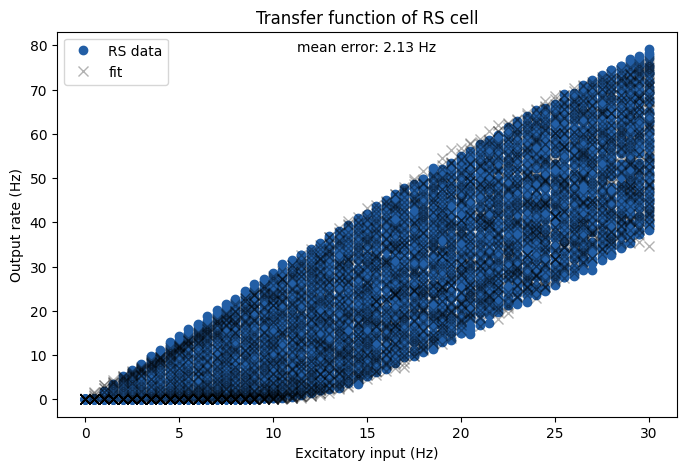

In [33]:
fig = plot_TF_fitting(neuron_model, df_RS, mean_error)
figs.append(fig)

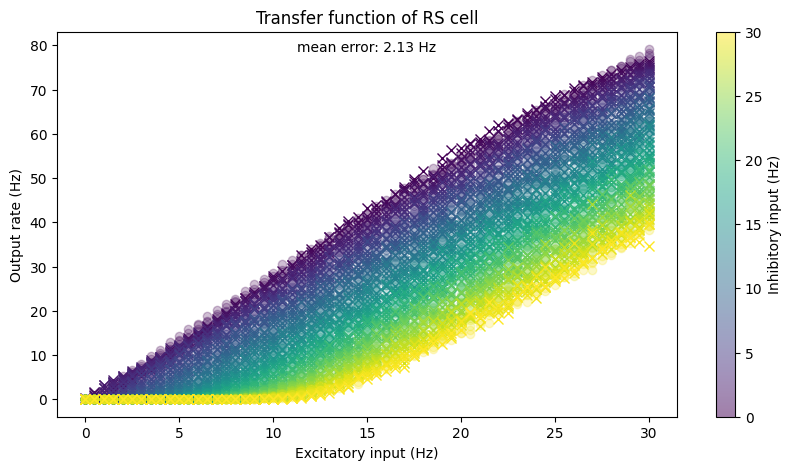

In [34]:
fig = plot_TF_fitting_viridis(neuron_model, df_RS, mean_error, unique_inh, colors)
figs.append(fig)

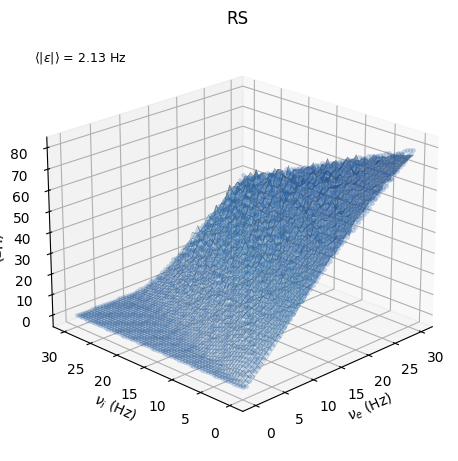

In [35]:
fig = mesh_3d_with_fitting('RS', df_RS, mean_error=mean_error)

WARNING    /home/ilariac/Documents/GitHub/ilaria_2_testing_pipeline/neuron-to-meanfield/utils/Plots_helper.py:1070: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()
 [py.warnings]


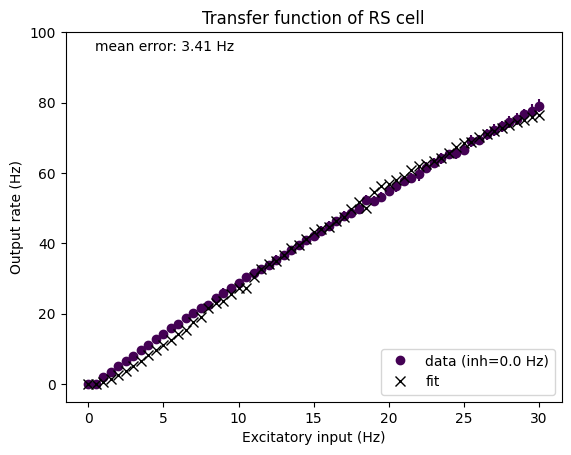

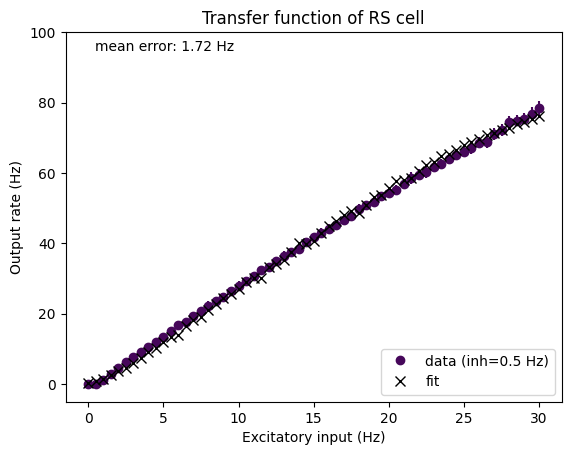

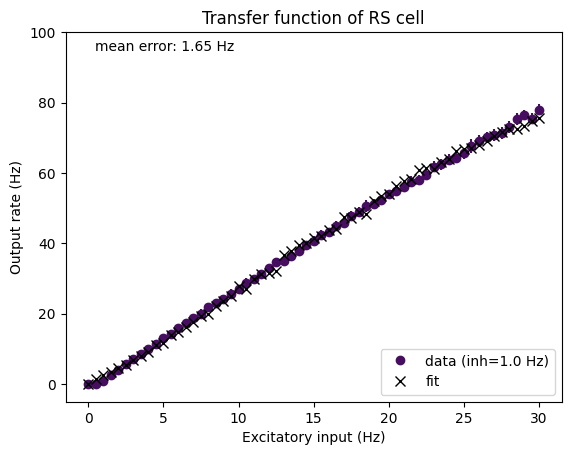

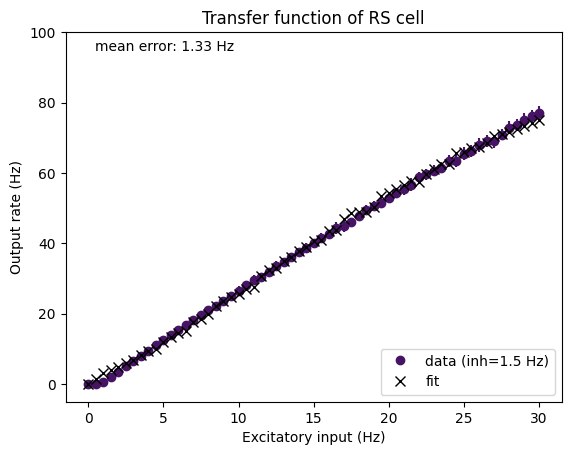

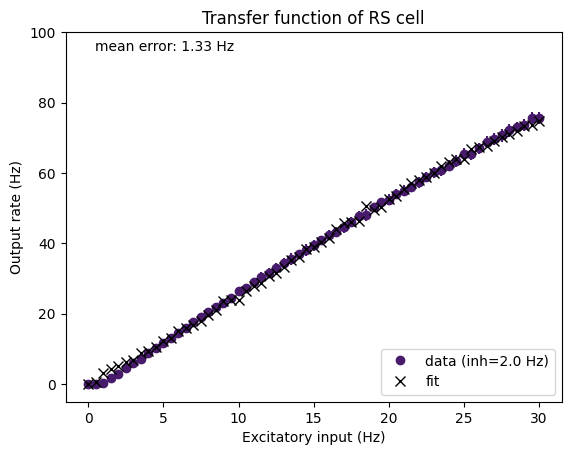

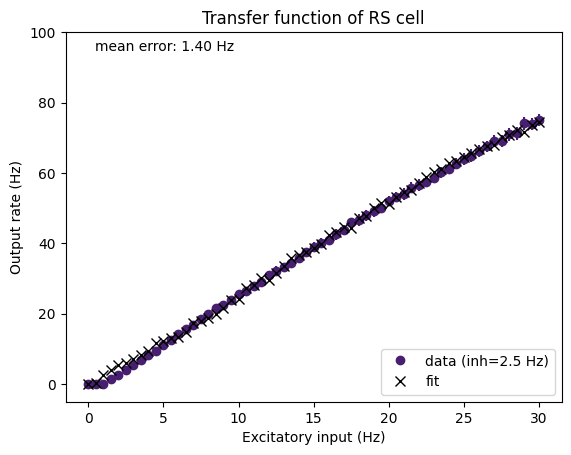

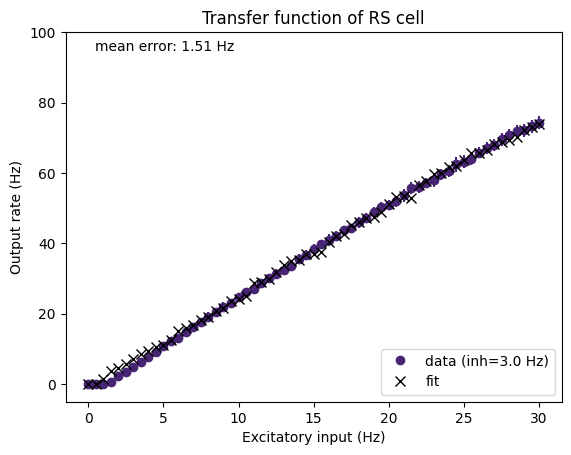

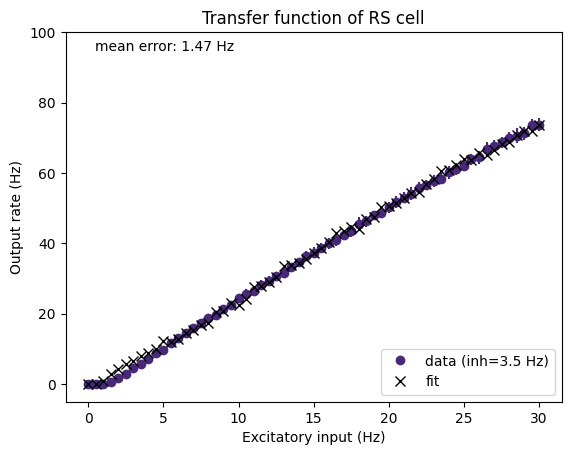

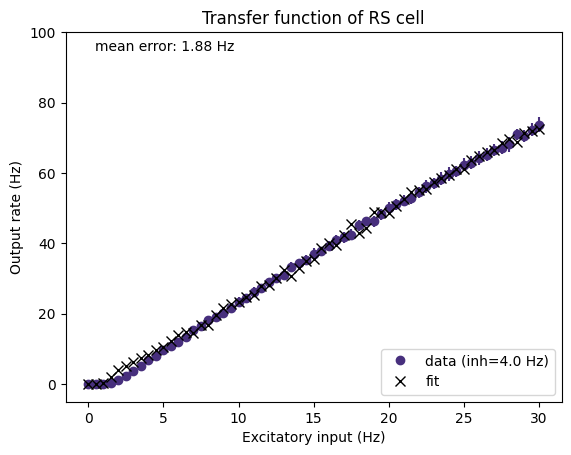

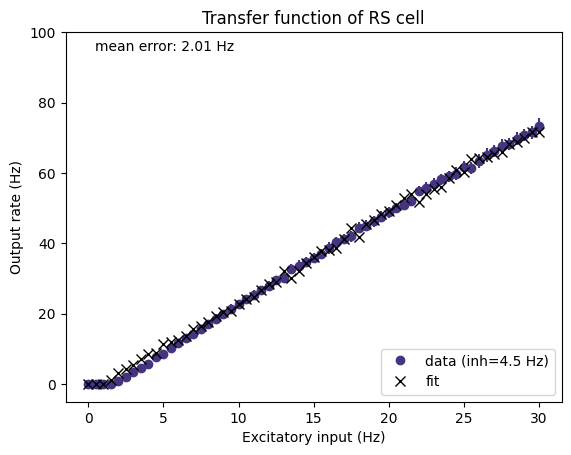

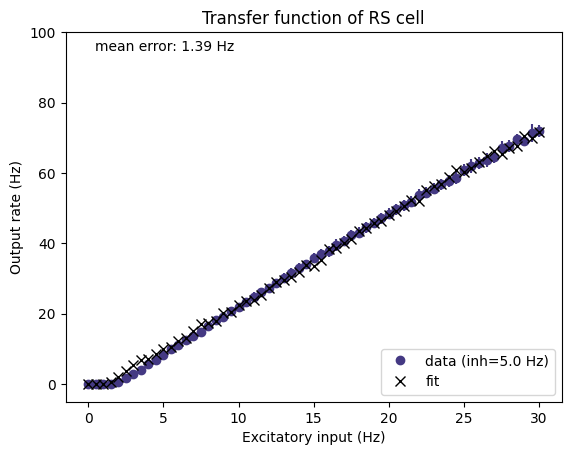

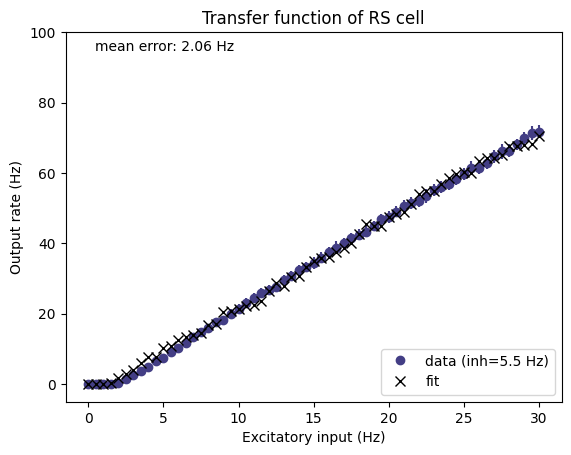

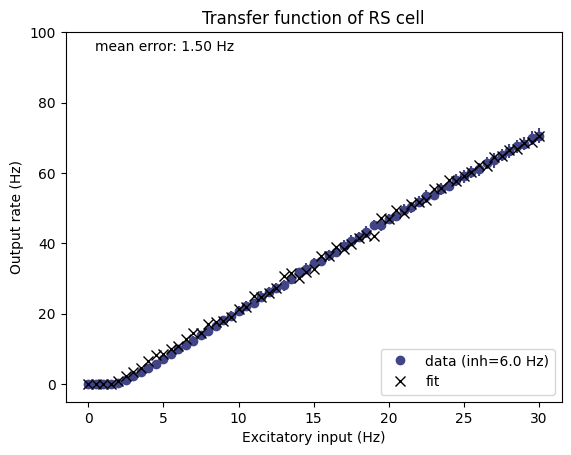

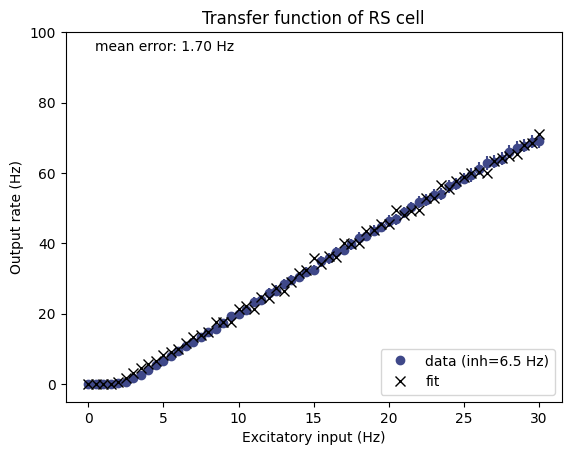

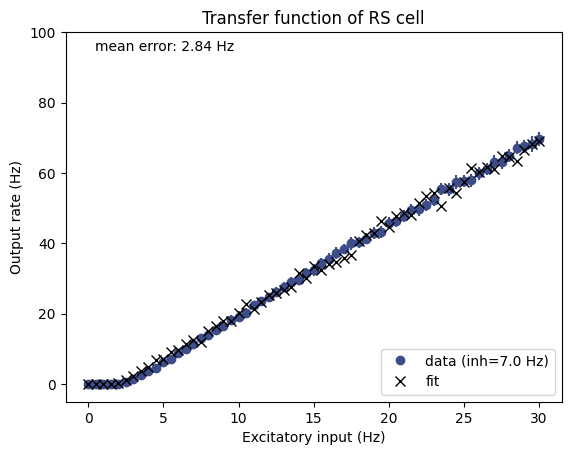

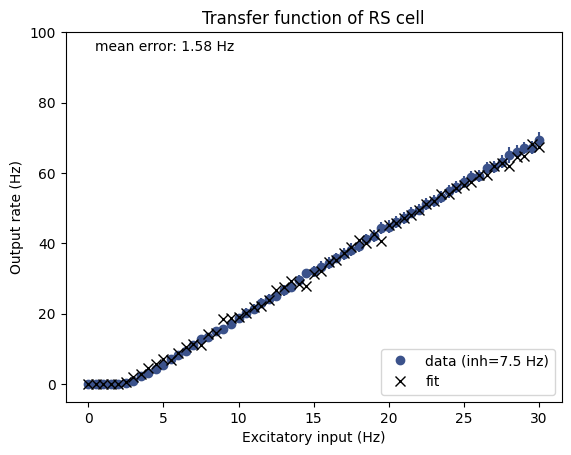

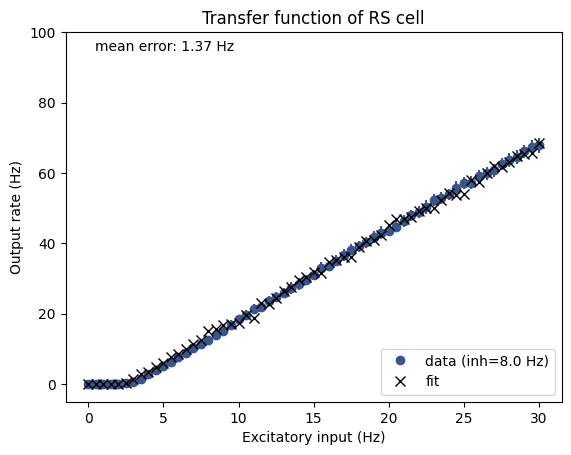

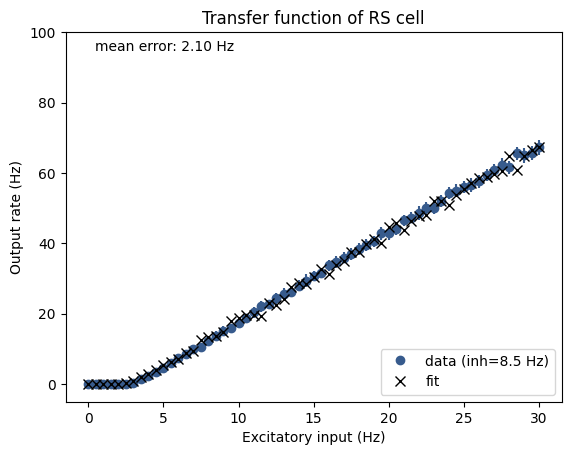

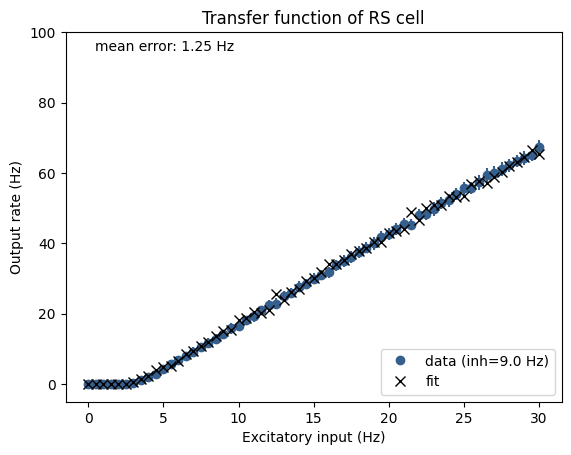

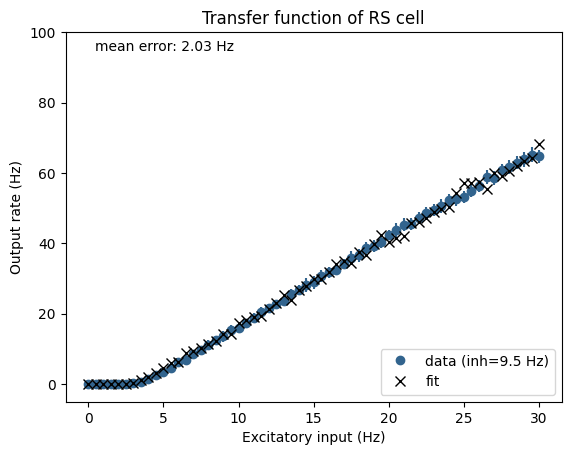

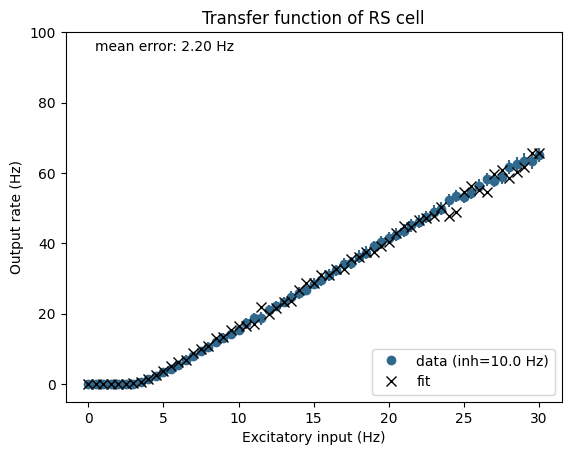

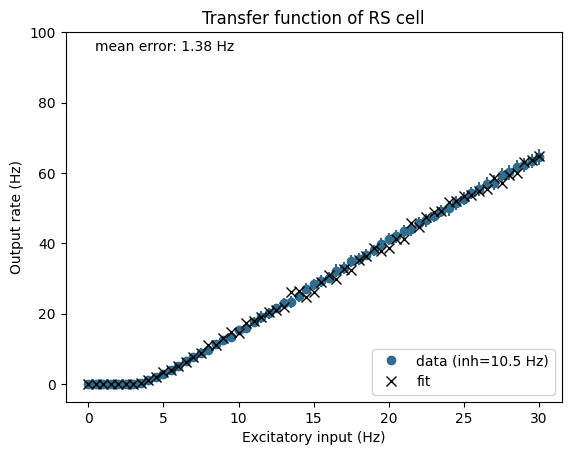

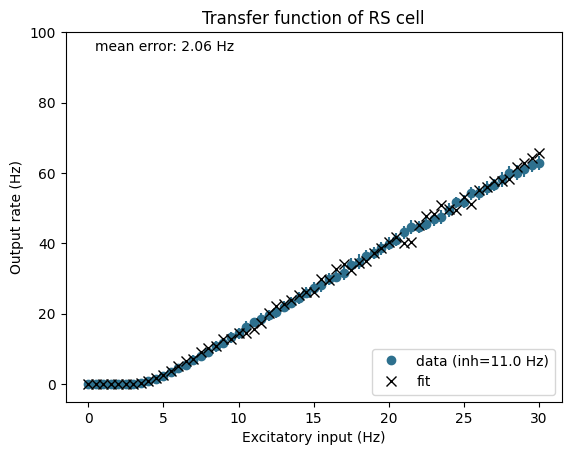

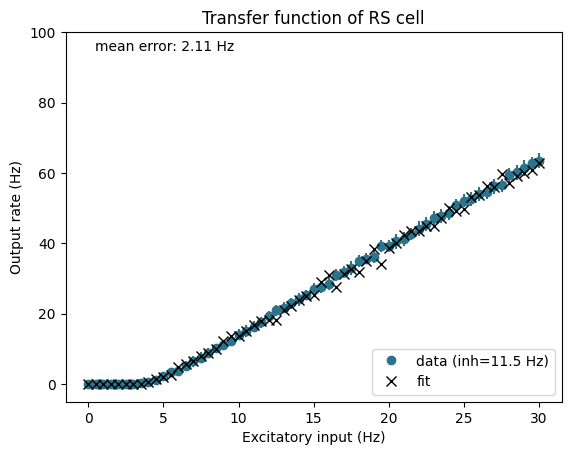

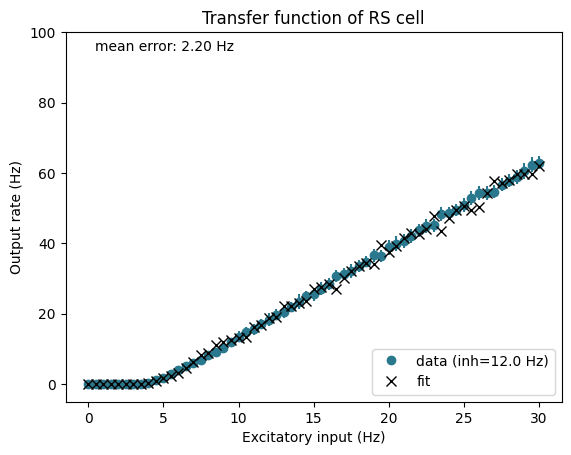

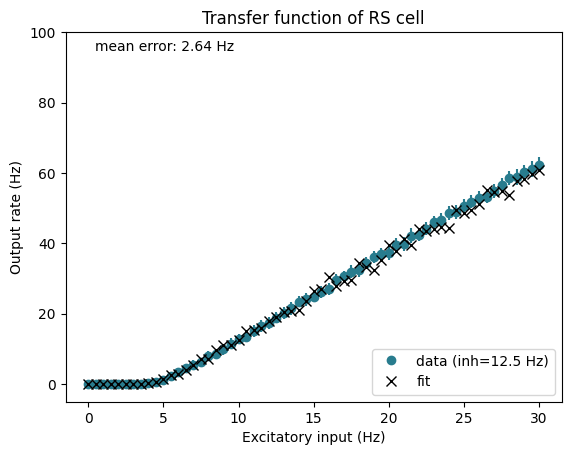

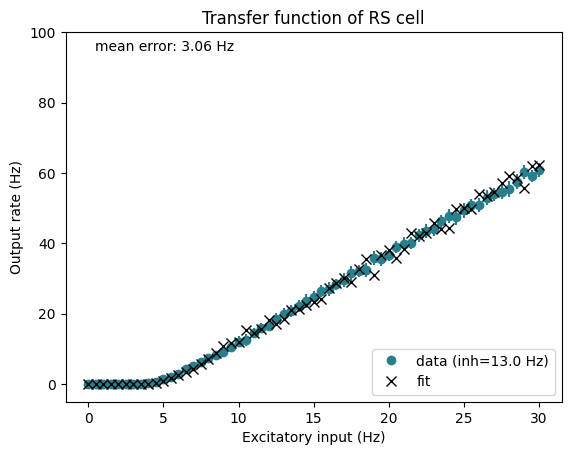

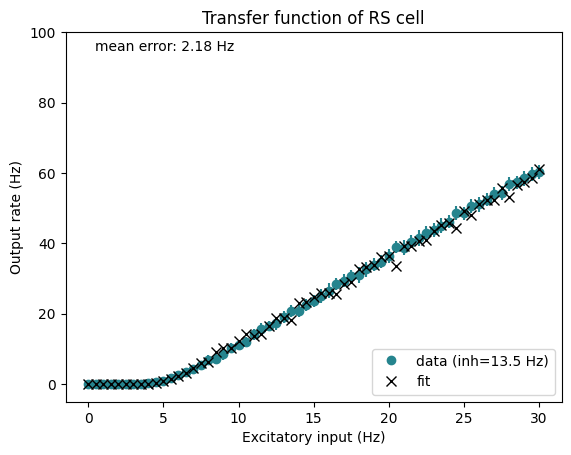

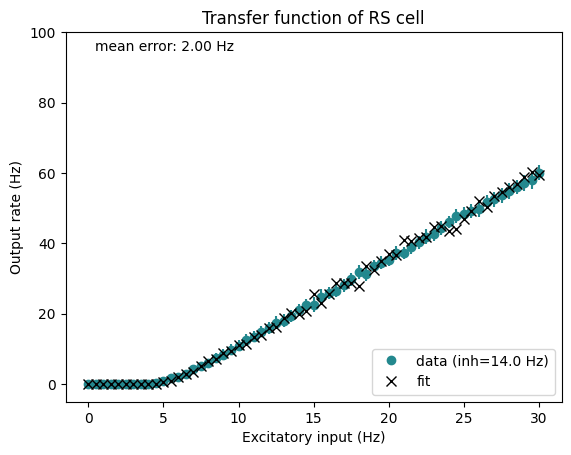

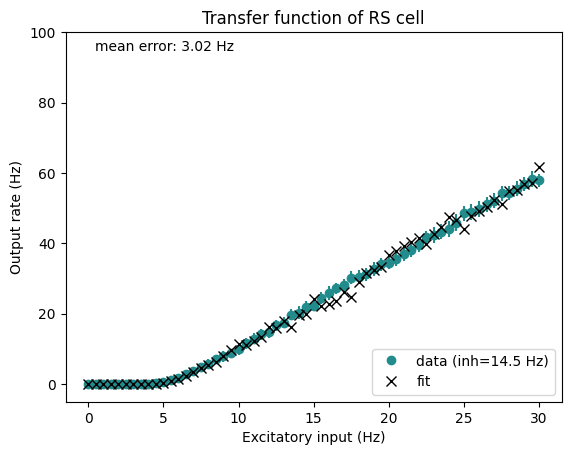

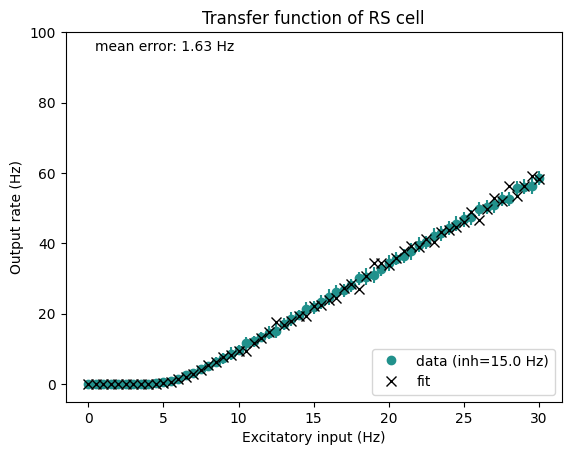

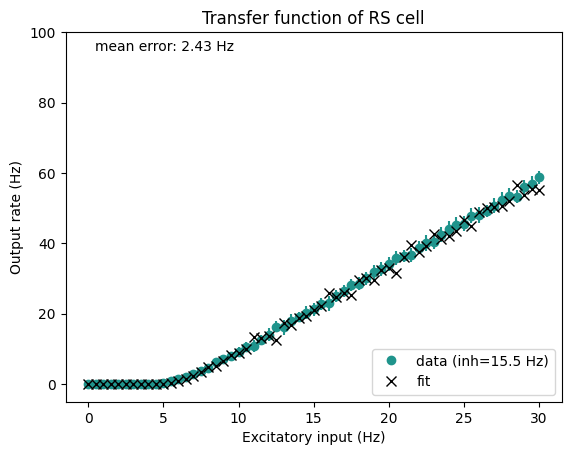

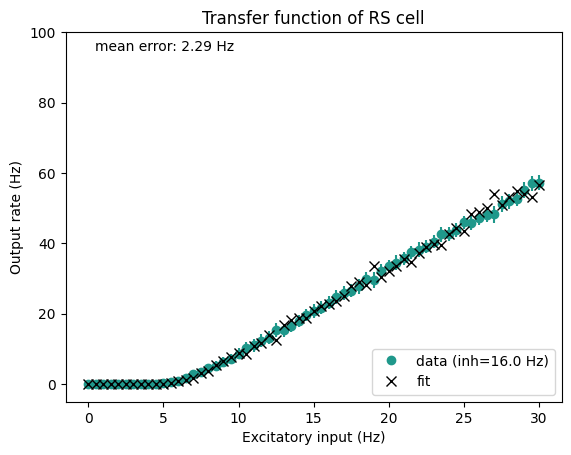

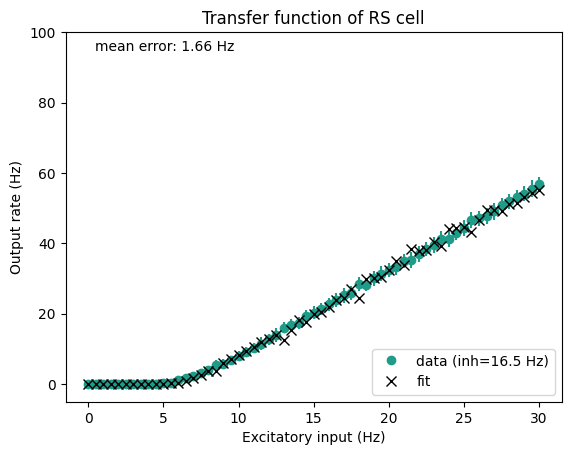

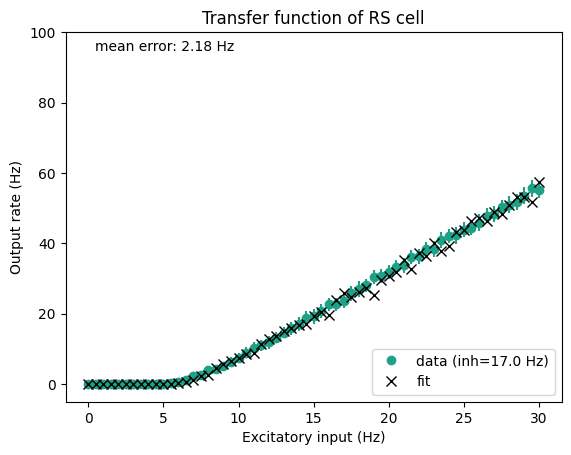

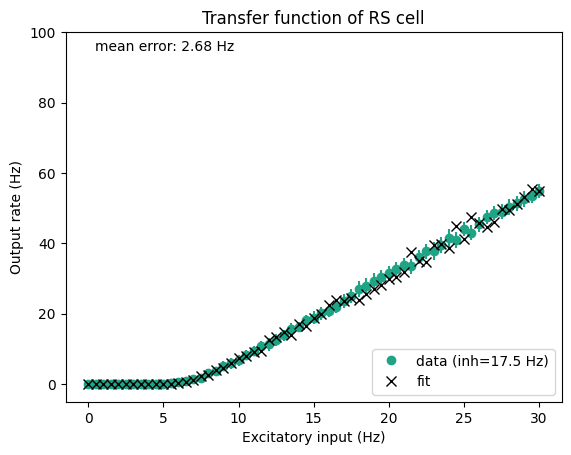

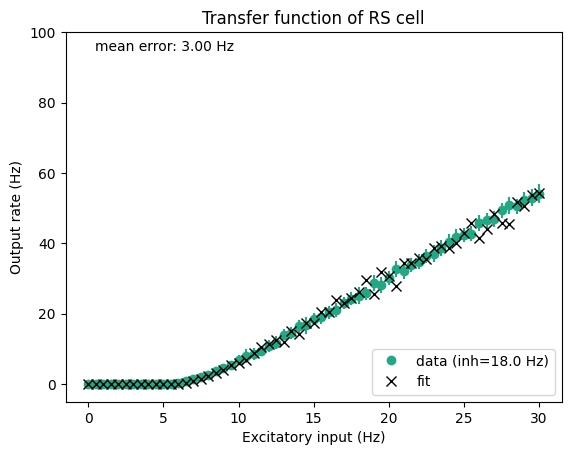

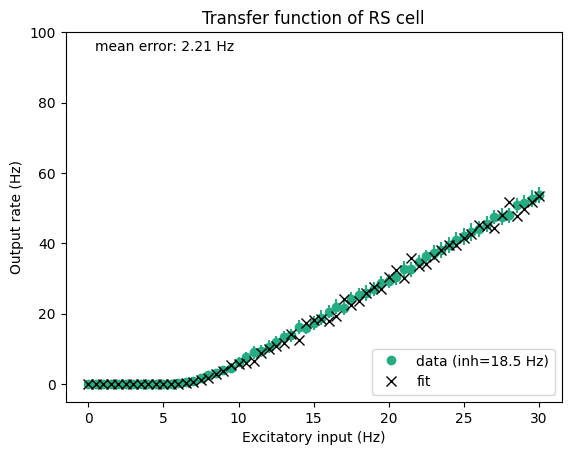

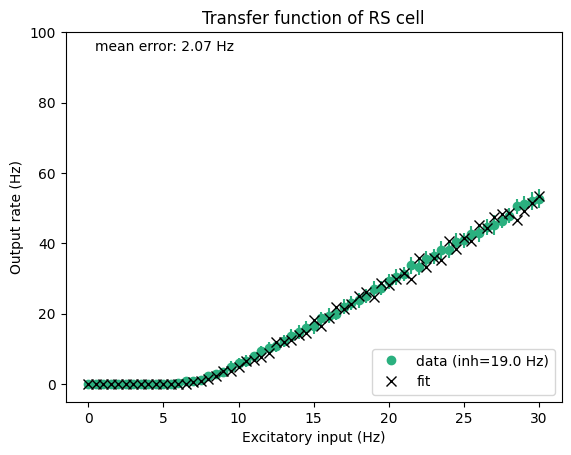

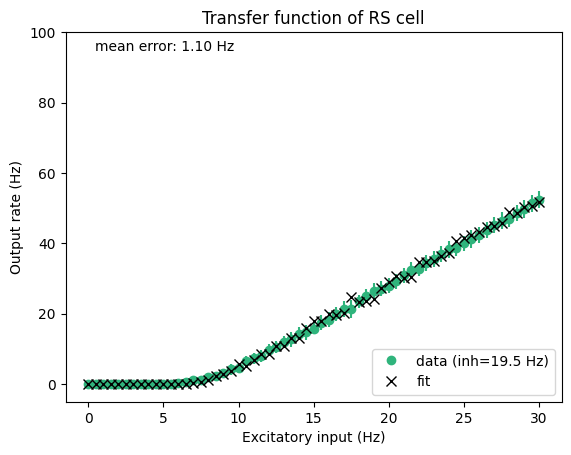

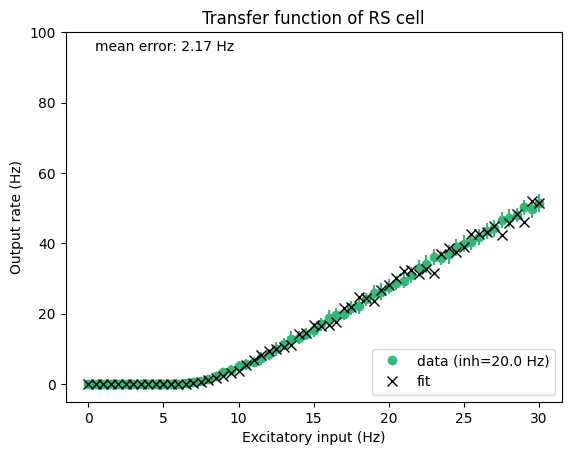

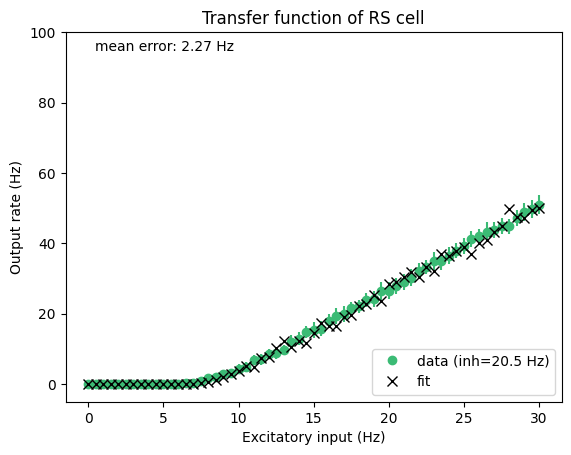

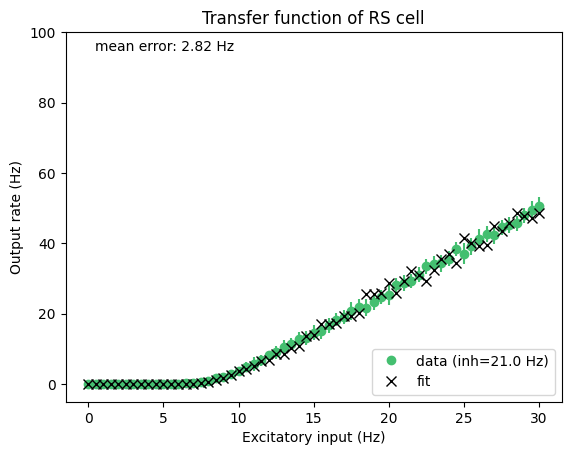

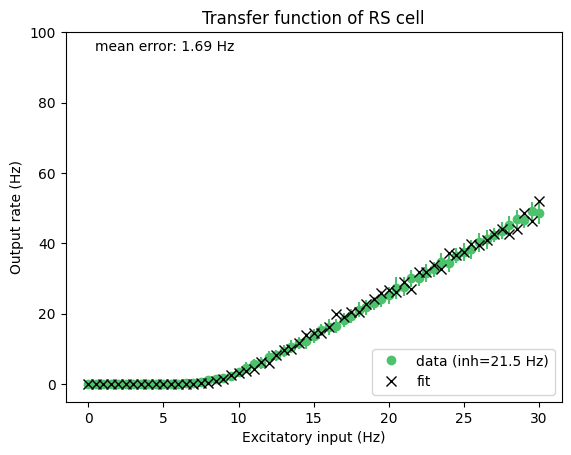

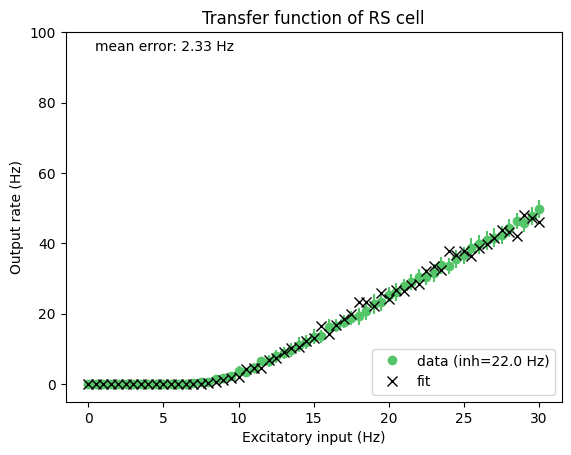

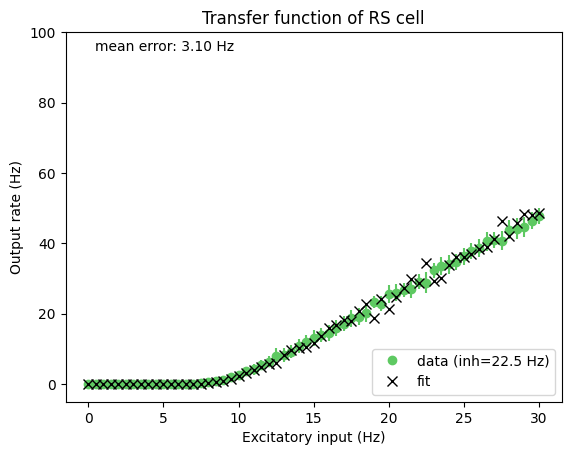

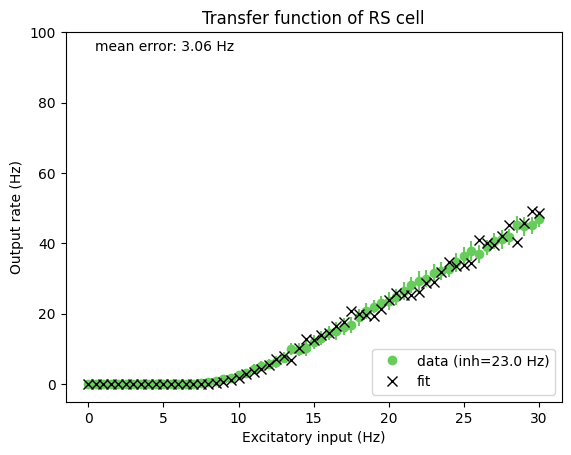

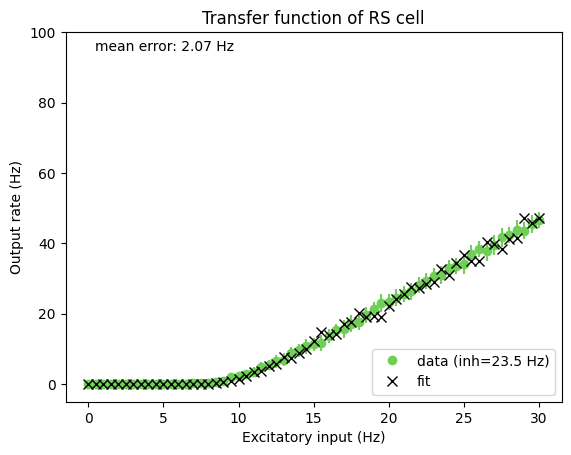

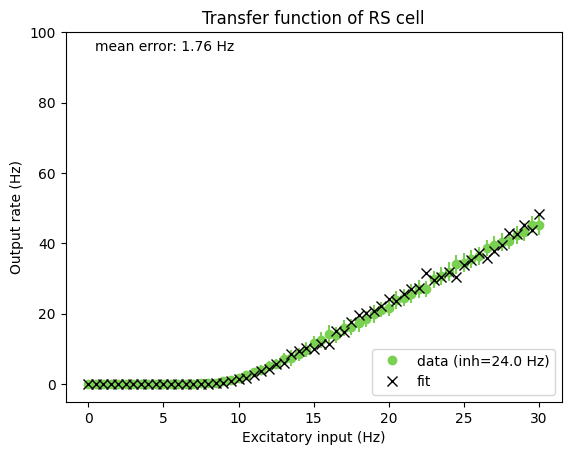

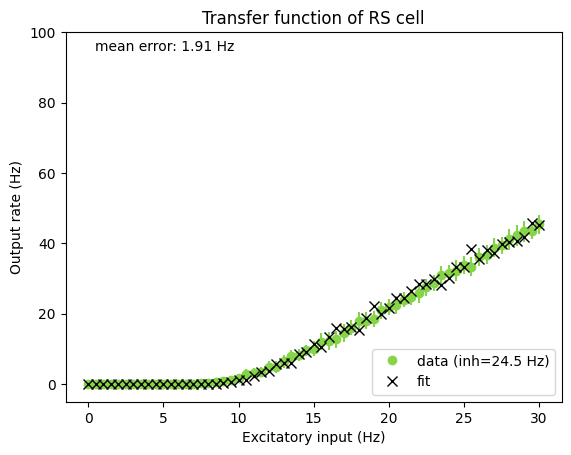

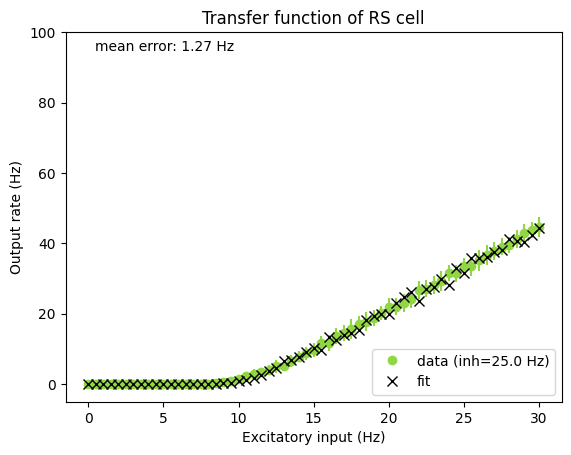

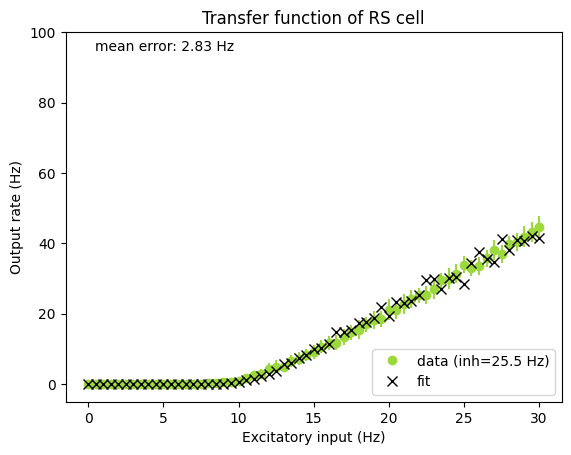

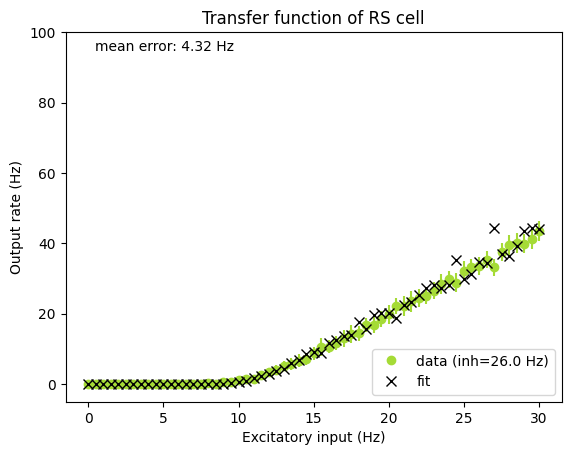

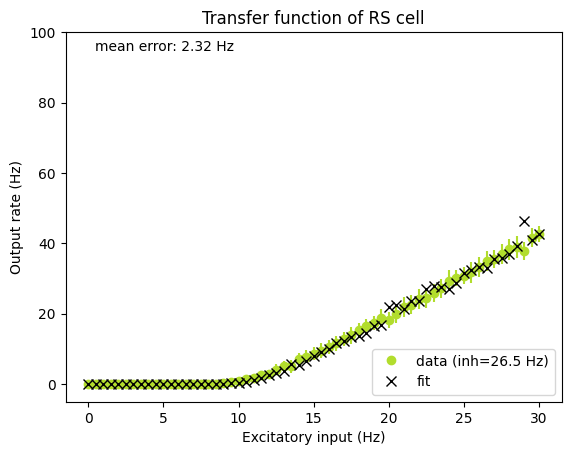

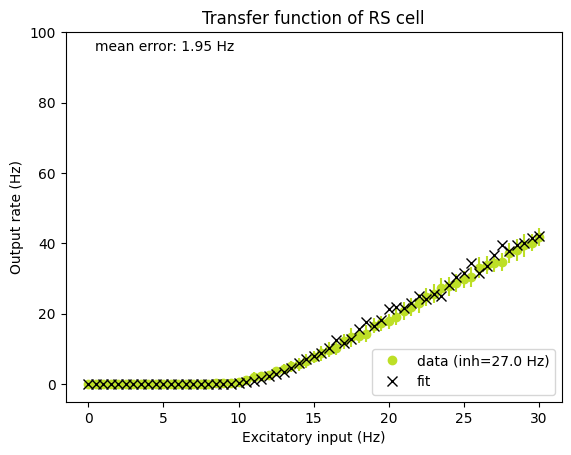

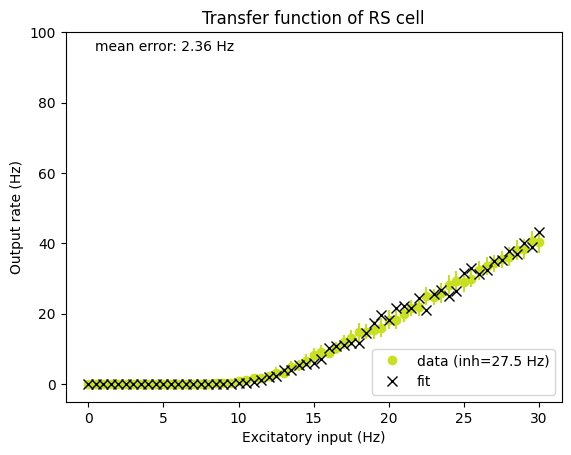

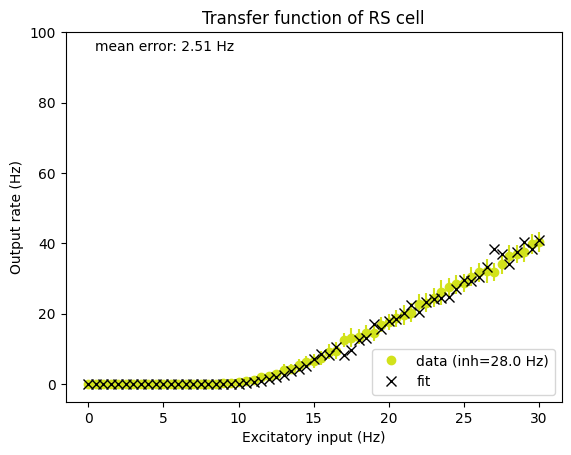

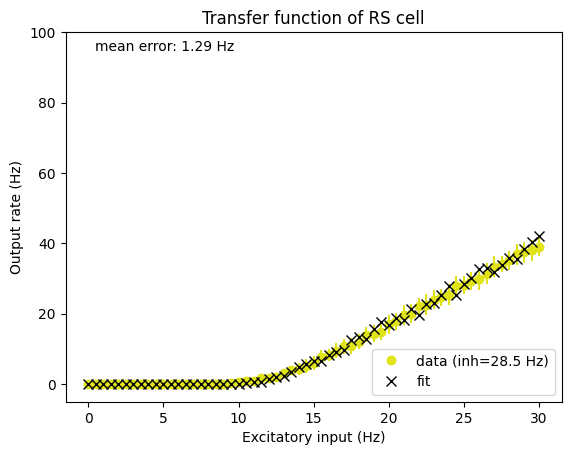

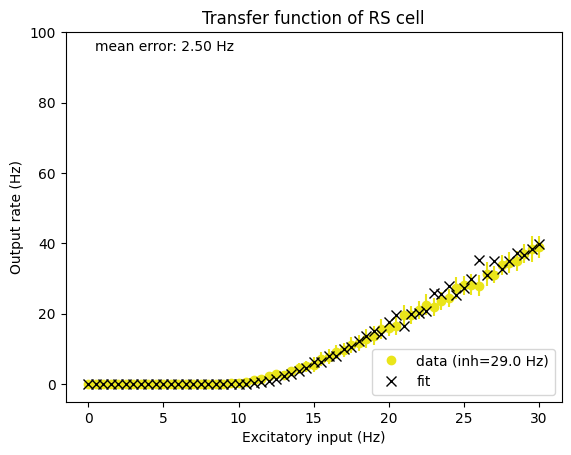

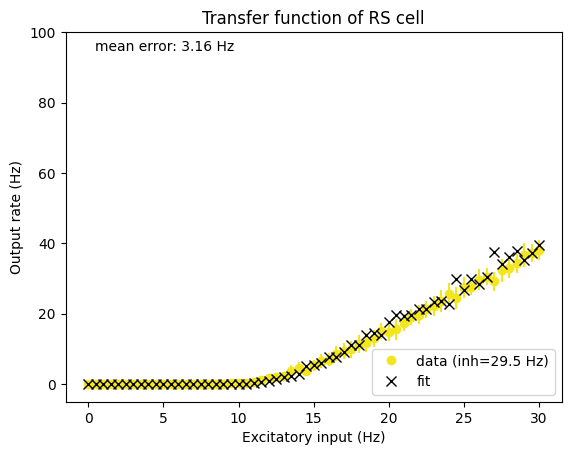

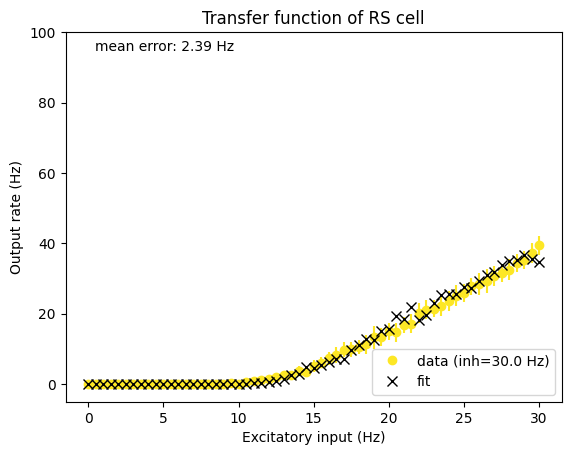

In [36]:
fig = plots_TF_fitting(neuron_model, df_RS, df_std_RS_slice_array, poly_params_2, params_SI, alpha, unique_inh, colors, y_lim=(-5, 100), w_ad = w_ad)

In [37]:
if display_gif == True:
    from IPython.display import HTML, display
    import base64

    # --- 1) save the GIF to disk ---
    gif_path = make_TF_gif(
        neuron_model, df_RS, df_std_RS_slice_array, poly_params_2, params_SI,
        alpha, unique_inh, colors,
        gif_name=gif_name,
        y_lim=(-5, 100),
        w_ad = w_ad)

    # --- 2) embed it inline so it animates in the notebook and is saved
    #        with it (survives reopening / sharing / re-runs) ---
    with open(gif_path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")
    display(HTML(f'<img src="data:image/gif;base64,{b64}" alt="{neuron_model} TF fit">'))

In [38]:
df_RS['residual']     = df_RS['avg_f_out'] - df_RS['fit_rate']
df_RS['abs_residual'] = np.abs(df_RS['residual'])

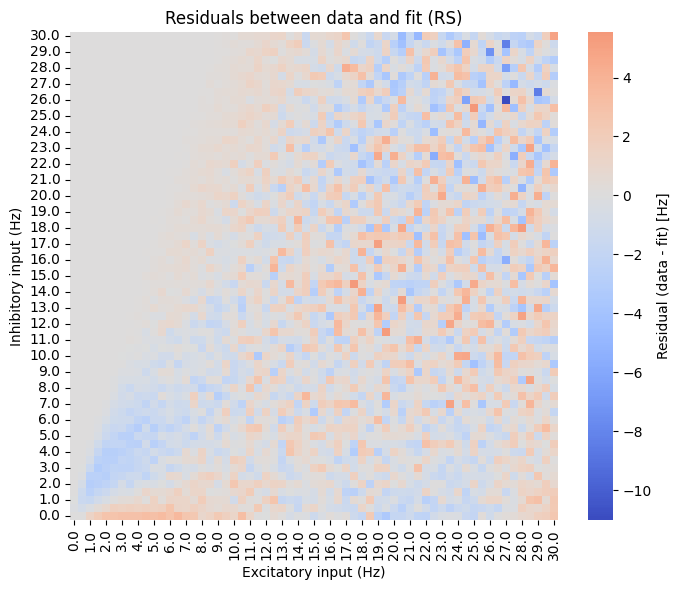

In [39]:
fig = plot_residuals_TF_fitting(neuron_model, df_RS)
figs.append(fig)

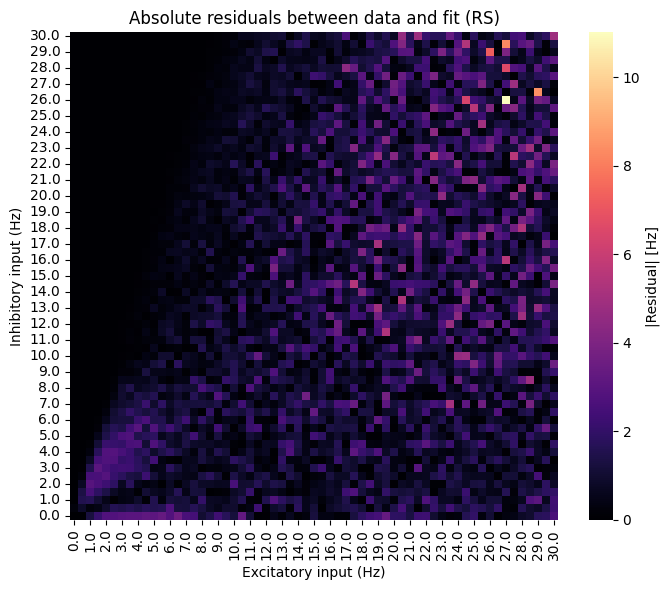

In [40]:
fig = plot_abs_residuals_TF_fitting(neuron_model, df_RS)
figs.append(fig)

In [41]:
save_figs(fig_path, fig_name + '_alpha_' + str(alpha), figs)